# CSC-44112 Assessment Part 2
# Cryptocurrency Market Segmentation using Clustering Algorithms
##Student ID:	25032580
##Github Link: https://github.com/Sohaib718/CSC44112-Part2

**Module:** Advanced Applications of AI and ML  
**Dataset:** Yahoo Finance via `yfinance (public)  
**Task:** Unsupervised clustering of cryptocurrencies by price/volume behaviour  



## SETUP — Install & Import Libraries

In [ ]:
# Install required packages
!pip install yfinance scikit-learn matplotlib seaborn pandas numpy scipy -q

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from scipy import stats

import yfinance as yf

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.impute import SimpleImputer

import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# Plot style
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'DejaVu Sans'
sns.set_theme(style='whitegrid')
print('All libraries loaded successfully.')

All libraries loaded successfully.


---
## DATA COLLECTION — Download Crypto Price Data

In [ ]:
# List of 30 major cryptocurrencies (Yahoo Finance tickers)
CRYPTOS = [
    'BTC-USD', 'ETH-USD', 'BNB-USD', 'XRP-USD', 'ADA-USD',
    'SOL-USD', 'DOGE-USD', 'DOT-USD', 'MATIC-USD', 'LTC-USD',
    'AVAX-USD', 'LINK-USD', 'UNI3-USD', 'XLM-USD', 'ATOM-USD',
    'ETC-USD', 'XMR-USD', 'BCH-USD', 'ALGO-USD', 'VET-USD',
    'FIL-USD', 'TRX-USD', 'THETA-USD', 'EOS-USD', 'AAVE-USD',
    'NEO-USD', 'CAKE-USD', 'GRT-USD', 'EGLD-USD', 'SAND-USD'
]

START_DATE = '2021-01-01'
END_DATE   = '2024-01-01'

print(f'Downloading data for {len(CRYPTOS)} cryptocurrencies...')
print(f'Period: {START_DATE} to {END_DATE}\n')

raw_data = {}
failed = []
for ticker in CRYPTOS:
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         progress=False, auto_adjust=True)
        if len(df) > 100:  # must have sufficient data
            raw_data[ticker] = df
            print(f'  ✓ {ticker:15s} — {len(df)} trading days')
        else:
            failed.append(ticker)
            print(f'  ✗ {ticker:15s} — insufficient data, skipped')
    except Exception as e:
        failed.append(ticker)
        print(f'  ✗ {ticker:15s} — error: {e}')

print(f'\nSuccessfully loaded: {len(raw_data)} coins')
print(f'Failed/skipped:      {len(failed)} coins')

Period: 2021-01-01 to 2024-01-01

  ✓ BTC-USD         — 1095 trading days
  ✓ ETH-USD         — 1095 trading days
  ✓ BNB-USD         — 1095 trading days
  ✓ XRP-USD         — 1095 trading days
  ✓ ADA-USD         — 1095 trading days
  ✓ SOL-USD         — 1095 trading days
  ✓ DOGE-USD        — 1095 trading days
  ✓ DOT-USD         — 1095 trading days
  ✓ MATIC-USD       — 1095 trading days
  ✓ LTC-USD         — 1095 trading days
  ✓ AVAX-USD        — 1095 trading days
  ✓ LINK-USD        — 1095 trading days


ERROR:yfinance:
1 Failed download:
ERROR:yfinance:['UNI3-USD']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-01-01 -> 2024-01-01)')


  ✗ UNI3-USD        — insufficient data, skipped
  ✓ XLM-USD         — 1095 trading days
  ✓ ATOM-USD        — 1095 trading days
  ✓ ETC-USD         — 1095 trading days
  ✓ XMR-USD         — 1095 trading days
  ✓ BCH-USD         — 1095 trading days
  ✓ ALGO-USD        — 1095 trading days
  ✓ VET-USD         — 1095 trading days
  ✓ FIL-USD         — 1095 trading days
  ✓ TRX-USD         — 1095 trading days
  ✓ THETA-USD       — 1095 trading days
  ✓ EOS-USD         — 1095 trading days
  ✓ AAVE-USD        — 1095 trading days
  ✓ NEO-USD         — 1095 trading days
  ✓ CAKE-USD        — 1095 trading days
  ✓ GRT-USD         — 456 trading days
  ✓ EGLD-USD        — 1095 trading days
  ✓ SAND-USD        — 1095 trading days

Successfully loaded: 29 coins
Failed/skipped:      1 coins


---
## [SECTION 3 - EDA] — Exploratory Data Analysis

### 3.1 Feature Engineering from Raw OHLCV Data

In [ ]:
# [SECTION 3 - EDA] Feature Engineering
# For each cryptocurrency, compute statistical features from daily price/volume data

def engineer_features(ticker, df):
    """Compute behavioural features for a single cryptocurrency."""
    close  = df['Close'].squeeze()
    volume = df['Volume'].squeeze()
    high   = df['High'].squeeze()
    low    = df['Low'].squeeze()

    # Daily returns
    daily_returns = close.pct_change().dropna()

    # Cumulative return over full period
    cum_return = (close.iloc[-1] / close.iloc[0]) - 1

    # Volatility (annualised std of daily returns)
    volatility = daily_returns.std() * np.sqrt(252)

    # Sharpe-like ratio (return / volatility, no risk-free rate)
    sharpe = (daily_returns.mean() * 252) / (volatility + 1e-9)

    # Skewness and kurtosis of return distribution
    skewness = daily_returns.skew()
    kurt     = daily_returns.kurt()

    # Maximum drawdown
    roll_max  = close.cummax()
    drawdown  = (close - roll_max) / roll_max
    max_dd    = drawdown.min()

    # Average daily range (High - Low) / Close — measures intraday volatility
    avg_range = ((high - low) / close).mean()

    # Volume features
    avg_volume     = volume.mean()
    volume_cv      = volume.std() / (volume.mean() + 1e-9)   # coefficient of variation

    # Positive return days ratio
    pos_days = (daily_returns > 0).mean()

    # Price trend: slope of linear fit (normalised)
    x = np.arange(len(close))
    slope, _, r_value, _, _ = stats.linregress(x, close.values)
    trend_slope = slope / (close.mean() + 1e-9)   # normalise by mean price
    trend_r2    = r_value ** 2

    return {
        'ticker':        ticker.replace('-USD', ''),
        'cum_return':    cum_return,
        'volatility':    volatility,
        'sharpe_ratio':  sharpe,
        'skewness':      skewness,
        'kurtosis':      kurt,
        'max_drawdown':  max_dd,
        'avg_range':     avg_range,
        'avg_volume':    avg_volume,
        'volume_cv':     volume_cv,
        'pos_days_ratio':pos_days,
        'trend_slope':   trend_slope,
        'trend_r2':      trend_r2,
    }

# Build feature table
records = [engineer_features(t, df) for t, df in raw_data.items()]
feat_df = pd.DataFrame(records).set_index('ticker')

print(f'Feature matrix shape: {feat_df.shape}')
print(f'Features: {list(feat_df.columns)}\n')
feat_df.round(4)

Feature matrix shape: (29, 12)
Features: ['cum_return', 'volatility', 'sharpe_ratio', 'skewness', 'kurtosis', 'max_drawdown', 'avg_range', 'avg_volume', 'volume_cv', 'pos_days_ratio', 'trend_slope', 'trend_r2']



,cum_return,volatility,sharpe_ratio,skewness,kurtosis,max_drawdown,avg_range,avg_volume,volume_cv,pos_days_ratio,trend_slope,trend_r2
ticker,,,,,,,,,,,,
BTC,0.4389,0.5355,0.4243,0.0637,3.4779,-0.7663,0.0453,3.180665e+10,0.6456,0.4918,-0.0007,0.3410
ETH,2.1237,0.6983,0.7260,0.0627,4.9743,-0.7935,0.0574,1.673251e+10,0.6820,0.5073,-0.0005,0.1528
BNB,7.2426,0.8215,0.9789,2.6605,36.0469,-0.7084,0.0580,1.633341e+09,0.9747,0.5201,-0.0004,0.1066
XRP,1.5898,0.9532,0.6682,3.0555,32.2947,-0.8325,0.0689,3.004618e+09,1.2764,0.5018,-0.0006,0.1873
ADA,2.3887,0.8347,0.7442,0.8707,4.9226,-0.9185,0.0702,1.838785e+09,1.3256,0.4982,-0.0016,0.4576
SOL,54.1038,1.0793,1.3941,0.3694,4.8968,-0.9627,0.0921,1.309630e+09,1.0961,0.5018,-0.0008,0.0688
DOGE,14.7383,2.1096,0.8442,18.2443,470.1188,-0.9226,0.0820,1.827809e+09,2.4007,0.4909,-0.0012,0.2469
DOT,-0.0136,0.8899,0.4379,0.5574,7.3913,-0.9323,0.0749,1.089278e+09,1.1972,0.4991,-0.0019,0.5859
MATIC,53.4918,1.1822,1.3251,2.0981,12.2684,-0.8795,0.0895,7.863578e+08,1.1684,0.5055,-0.0002,0.0199


### 3.2 Descriptive Statistics

In [ ]:
# [SECTION 3 - EDA] Descriptive Statistics
print('=== Descriptive Statistics ===')
desc = feat_df.describe().T
desc.columns = ['count','mean','std','min','25%','50%','75%','max']
print(desc.round(4).to_string())

=== Descriptive Statistics ===
                count          mean           std           min           25%           50%           75%           max
cum_return       29.0  5.935700e+00  1.389820e+01 -6.891000e-01 -2.600000e-02  7.945000e-01  2.996800e+00  5.410380e+01
volatility       29.0  1.239400e+00  1.539400e+00  5.355000e-01  8.485000e-01  9.137000e-01  1.011700e+00  9.121000e+00
sharpe_ratio     29.0  6.541000e-01  3.250000e-01  1.560000e-01  4.243000e-01  6.292000e-01  8.442000e-01  1.394100e+00
skewness         29.0  2.105200e+00  4.106000e+00 -1.860000e-01  3.612000e-01  8.374000e-01  1.612600e+00  1.824430e+01
kurtosis         29.0  3.546610e+01  9.250670e+01  3.477900e+00  4.922600e+00  1.077780e+01  1.527770e+01  4.701188e+02
max_drawdown     29.0 -9.000000e-01  8.040000e-02 -9.915000e-01 -9.605000e-01 -9.226000e-01 -8.795000e-01 -6.961000e-01
avg_range        29.0  7.710000e-02  1.950000e-02  4.530000e-02  6.560000e-02  7.630000e-02  8.290000e-02  1.562000e-01
avg_volum

### 3.3 Missing Data Analysis

In [ ]:
# [SECTION 3 - EDA] Missing Data Analysis
missing = feat_df.isnull().sum()
print('Missing values per feature:')
print(missing[missing > 0] if missing.any() else 'No missing values found.')

# Handle any missing values
imputer = SimpleImputer(strategy='median')
feat_df_clean = pd.DataFrame(
    imputer.fit_transform(feat_df),
    index=feat_df.index,
    columns=feat_df.columns
)
print(f'\nCleaned dataset shape: {feat_df_clean.shape}')

Missing values per feature:
No missing values found.

Cleaned dataset shape: (29, 12)


### 3.4 Feature Distributions

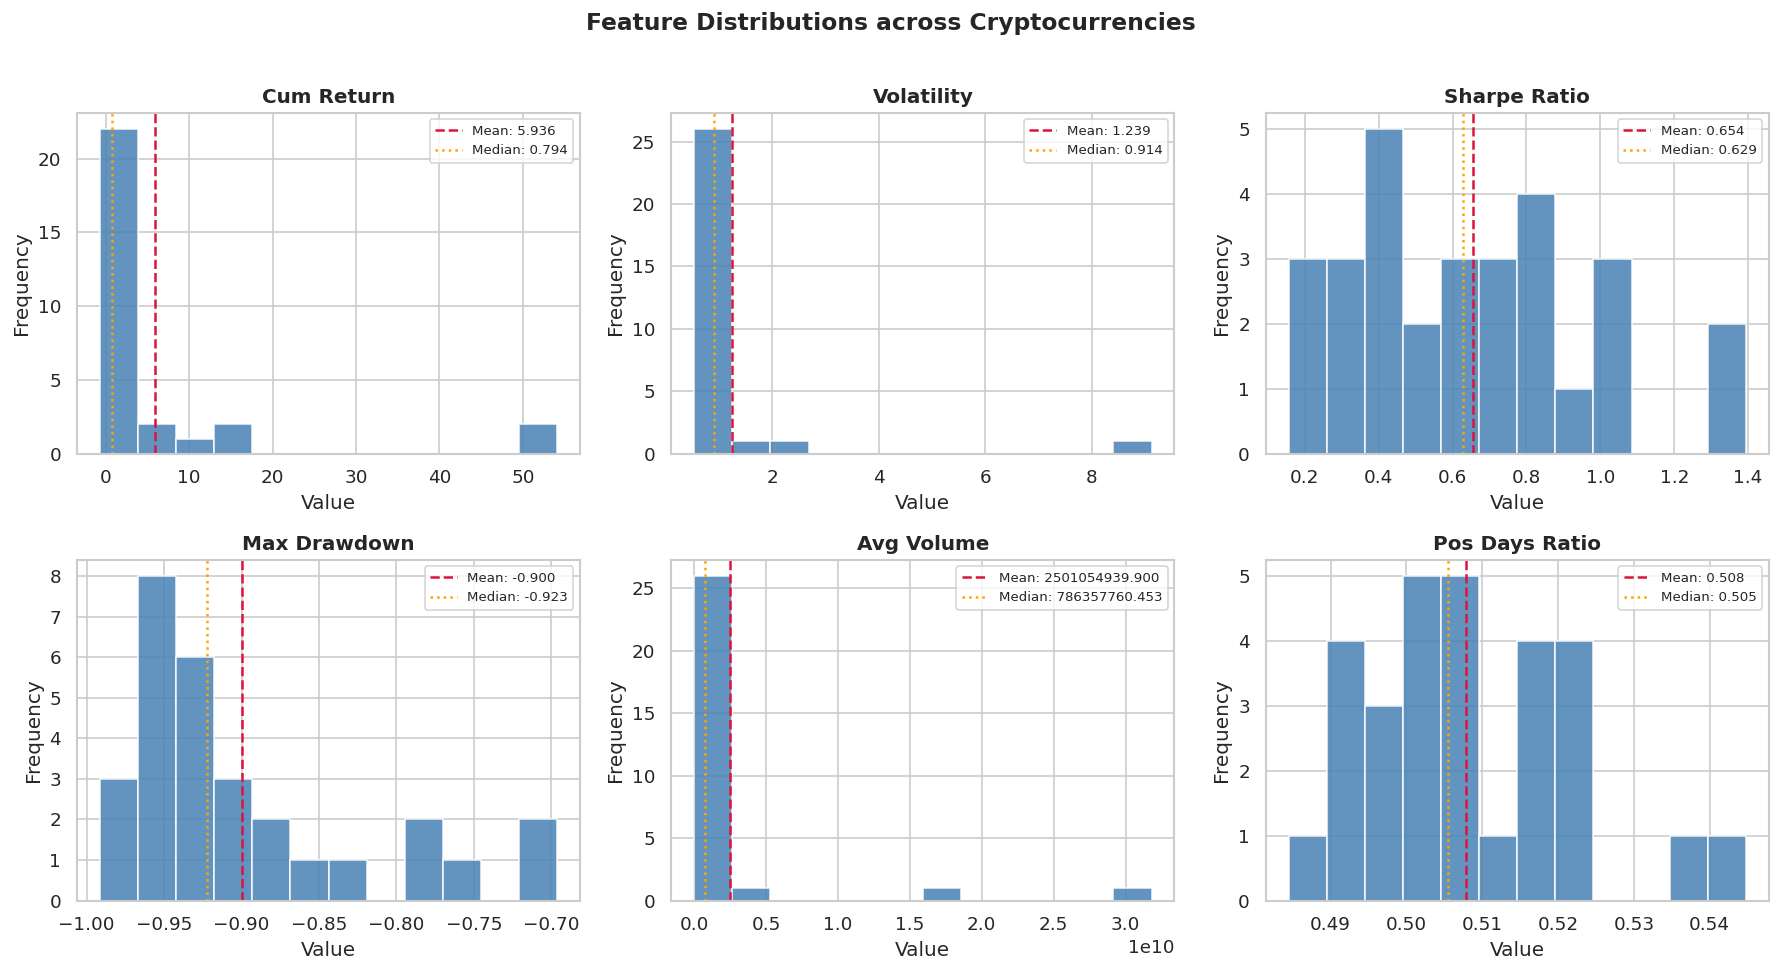

Figure saved: eda_distributions.png


In [ ]:
# [SECTION 3 - EDA] Feature Distribution Plots
features_to_plot = ['cum_return', 'volatility', 'sharpe_ratio',
                    'max_drawdown', 'avg_volume', 'pos_days_ratio']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    ax = axes[i]
    data = feat_df_clean[feat]
    ax.hist(data, bins=12, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(data.mean(), color='crimson', linestyle='--', linewidth=1.5, label=f'Mean: {data.mean():.3f}')
    ax.axvline(data.median(), color='orange', linestyle=':', linewidth=1.5, label=f'Median: {data.median():.3f}')
    ax.set_title(feat.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=8)

plt.suptitle('Feature Distributions across Cryptocurrencies', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_distributions.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: eda_distributions.png')

### 3.5 Correlation Heatmap

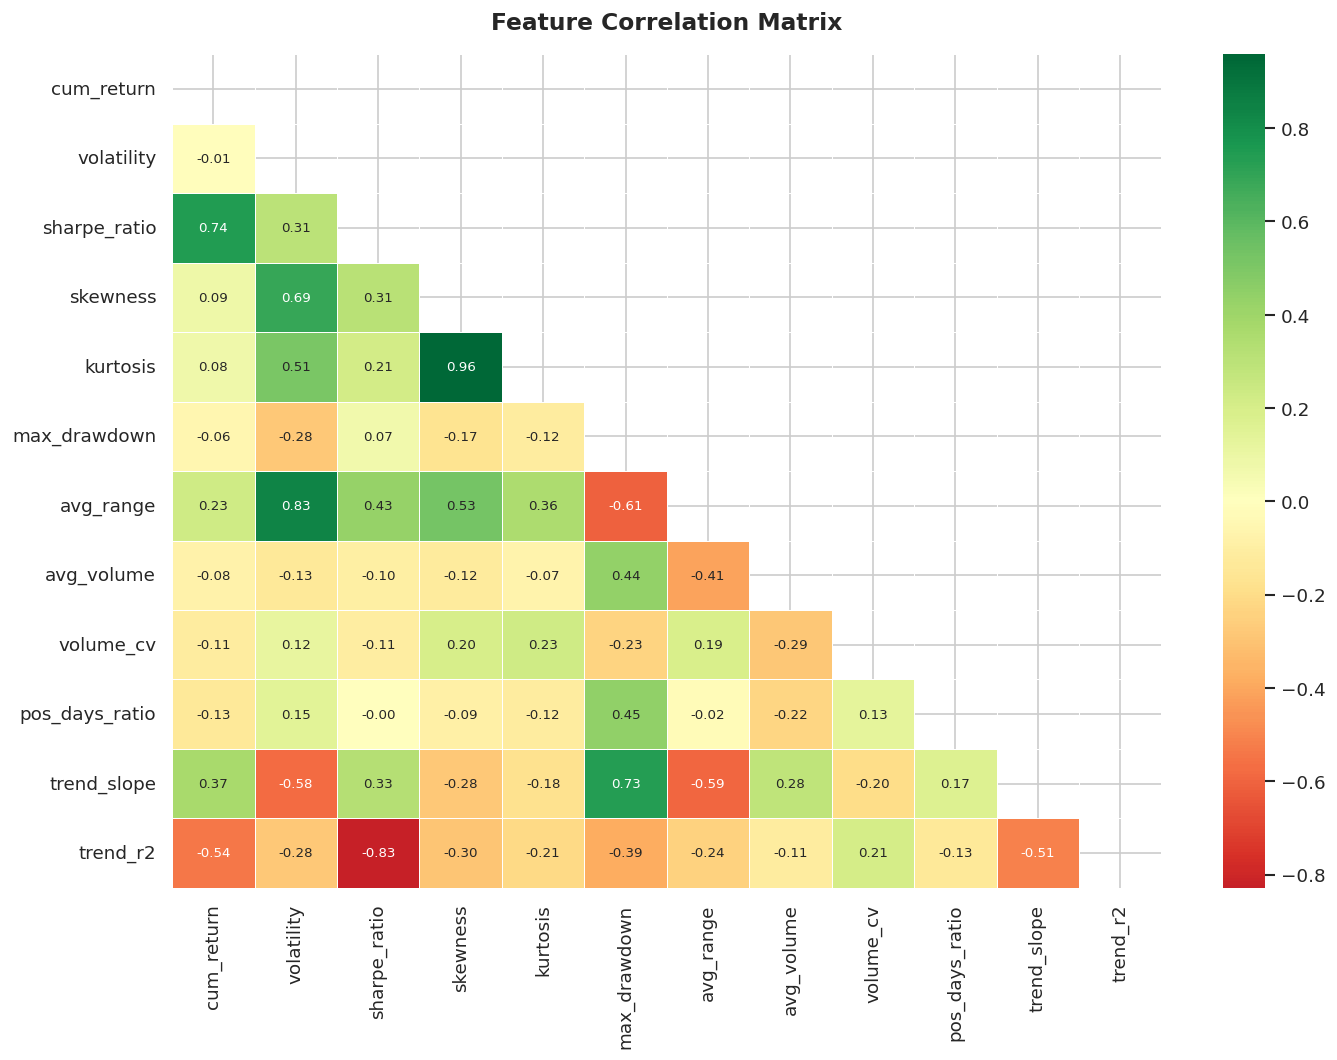

Figure saved: eda_correlation.png

Top 5 correlated feature pairs:
kurtosis      skewness        0.959
volatility    avg_range       0.834
trend_r2      sharpe_ratio    0.829
sharpe_ratio  cum_return      0.744
max_drawdown  trend_slope     0.730


In [ ]:
# [SECTION 3 - EDA] Correlation Heatmap
fig, ax = plt.subplots(figsize=(12, 9))
corr = feat_df_clean.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.5, ax=ax,
            annot_kws={'size': 8})
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('eda_correlation.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: eda_correlation.png')

# Report top correlations
corr_pairs = corr.abs().unstack().sort_values(ascending=False)
corr_pairs = corr_pairs[corr_pairs < 1.0].drop_duplicates()
print('\nTop 5 correlated feature pairs:')
print(corr_pairs.head(5).round(3).to_string())

### 3.6 Volatility vs Return Scatter (per coin)

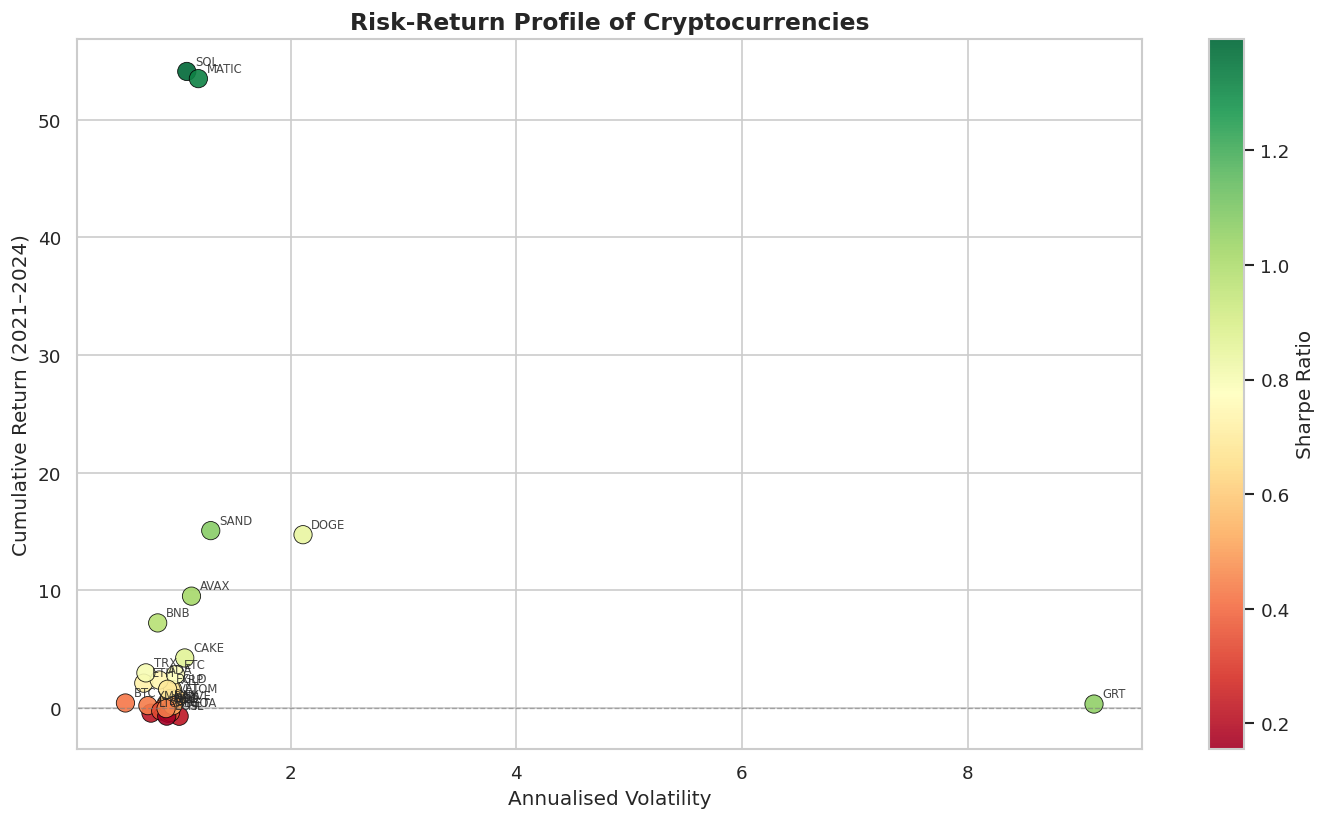

Figure saved: eda_risk_return.png


In [ ]:
# [SECTION 3 - EDA] Risk-Return Profile Plot
fig, ax = plt.subplots(figsize=(12, 7))

scatter = ax.scatter(
    feat_df_clean['volatility'],
    feat_df_clean['cum_return'],
    c=feat_df_clean['sharpe_ratio'],
    cmap='RdYlGn', s=120, edgecolors='black', linewidths=0.5, alpha=0.9
)
plt.colorbar(scatter, ax=ax, label='Sharpe Ratio')

# Annotate each coin
for ticker in feat_df_clean.index:
    ax.annotate(ticker,
                (feat_df_clean.loc[ticker, 'volatility'],
                 feat_df_clean.loc[ticker, 'cum_return']),
                textcoords='offset points', xytext=(5, 4), fontsize=7, alpha=0.85)

ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.6)
ax.set_xlabel('Annualised Volatility', fontsize=12)
ax.set_ylabel('Cumulative Return (2021–2024)', fontsize=12)
ax.set_title('Risk-Return Profile of Cryptocurrencies', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_risk_return.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: eda_risk_return.png')

### 3.7 Pairplot of Key Features

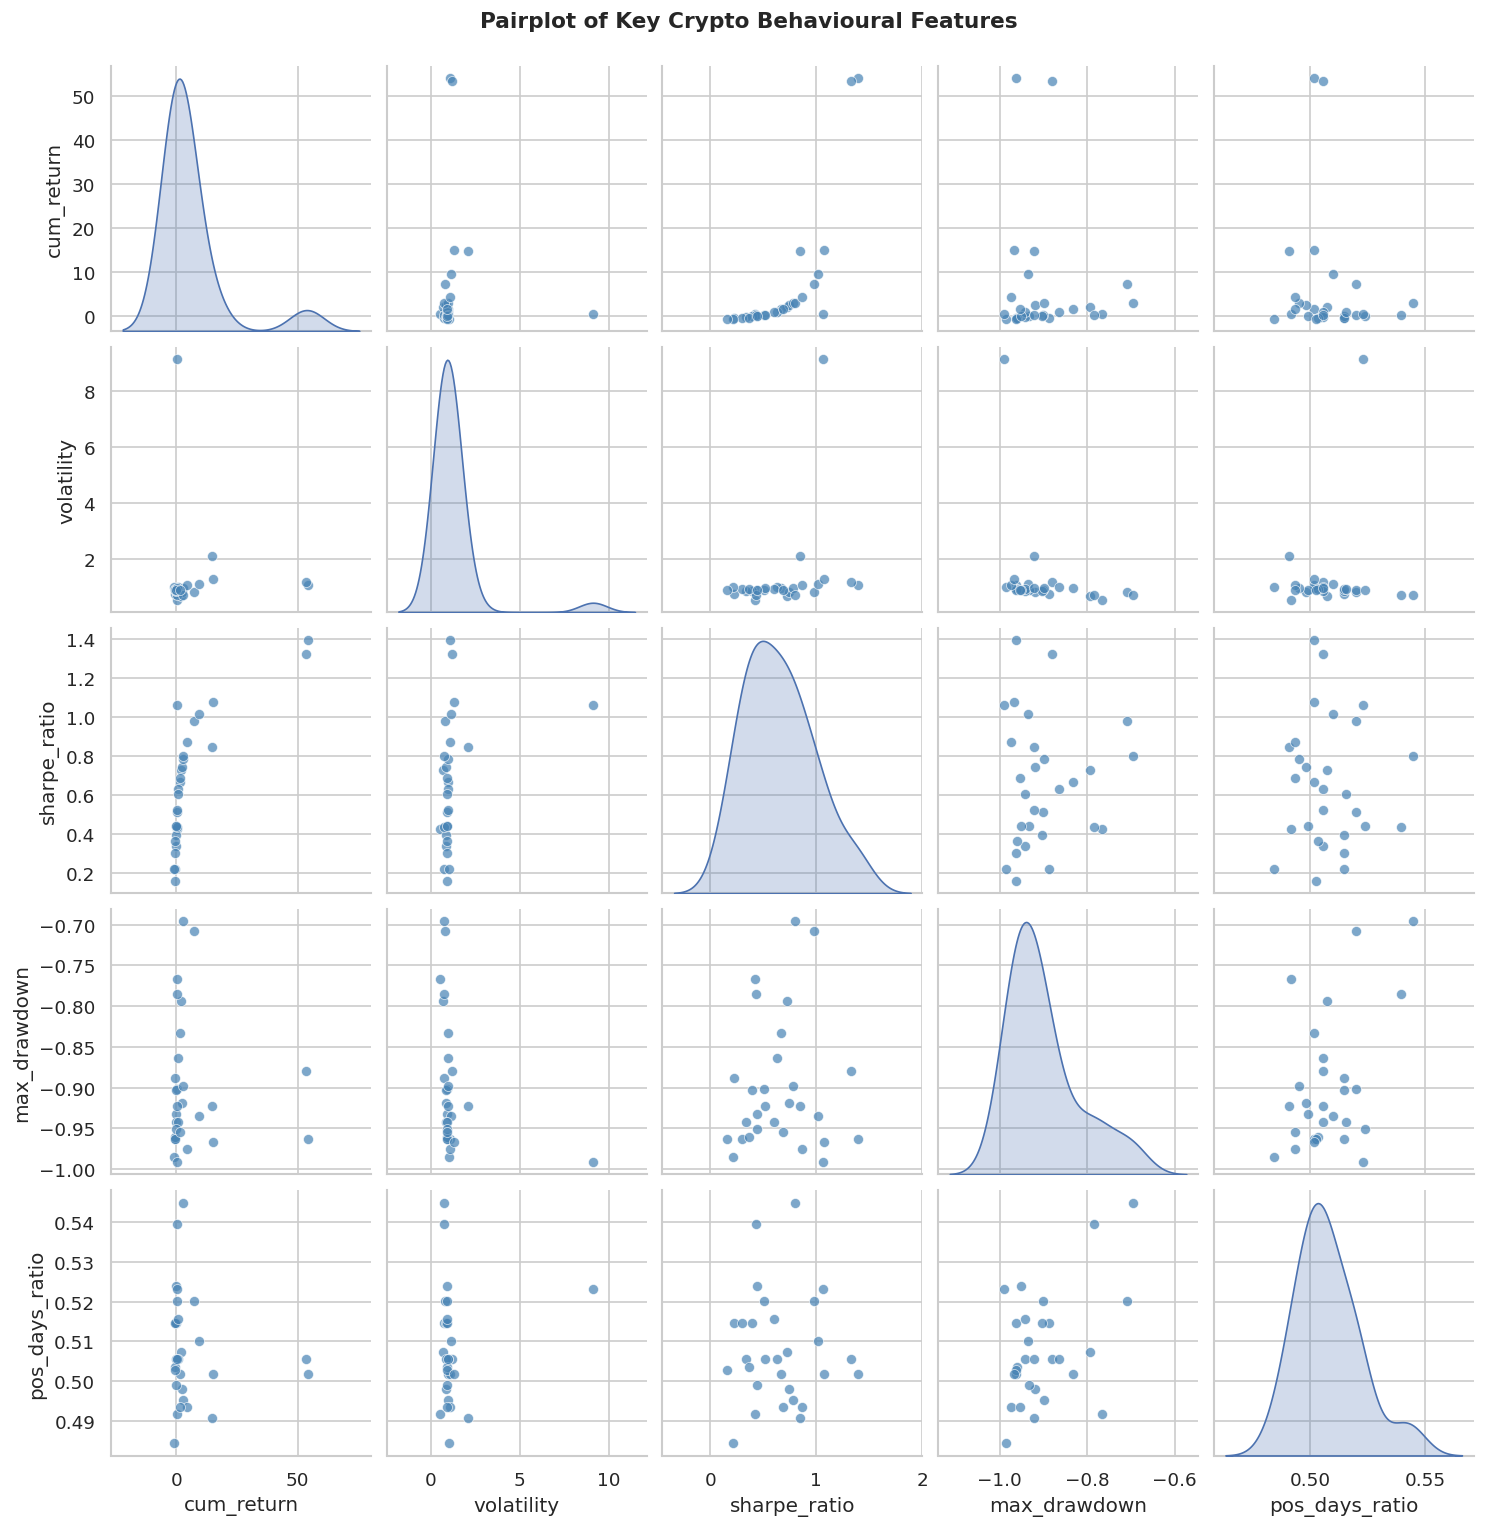

Figure saved: eda_pairplot.png


In [ ]:
# [SECTION 3 - EDA] Pairplot of Selected Features
pair_features = ['cum_return', 'volatility', 'sharpe_ratio', 'max_drawdown', 'pos_days_ratio']
pair_df = feat_df_clean[pair_features].copy()

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws={'alpha': 0.7, 'color': 'steelblue'})
g.figure.suptitle('Pairplot of Key Crypto Behavioural Features', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('eda_pairplot.png', bbox_inches='tight', dpi=120)
plt.show()
print('Figure saved: eda_pairplot.png')

---
## [SECTION 4 - METHODOLOGY] — Preprocessing & Model Development

### 4.1 Feature Scaling

In [ ]:
# [SECTION 4 - METHODOLOGY] StandardScaler Preprocessing
# Clustering algorithms are distance-based — scaling is critical

scaler = StandardScaler()
X_scaled = scaler.fit_transform(feat_df_clean)
X_scaled_df = pd.DataFrame(X_scaled, index=feat_df_clean.index, columns=feat_df_clean.columns)

print('Scaling applied: StandardScaler (zero mean, unit variance)')
print(f'Scaled matrix shape: {X_scaled.shape}')
print('\nPost-scaling stats (should be ~0 mean, ~1 std):')
print(pd.DataFrame(X_scaled, columns=feat_df_clean.columns).describe().loc[['mean','std']].round(3))

Scaling applied: StandardScaler (zero mean, unit variance)
Scaled matrix shape: (29, 12)

Post-scaling stats (should be ~0 mean, ~1 std):
      cum_return  volatility  sharpe_ratio  skewness  kurtosis  max_drawdown  \
mean      -0.000       0.000         0.000     0.000     0.000         0.000   
std        1.018       1.018         1.018     1.018     1.018         1.018   

      avg_range  avg_volume  volume_cv  pos_days_ratio  trend_slope  trend_r2  
mean     -0.000      -0.000      0.000          -0.000        0.000     0.000  
std       1.018       1.018      1.018           1.018        1.018     1.018  


### 4.2 PCA for Dimensionality Reduction

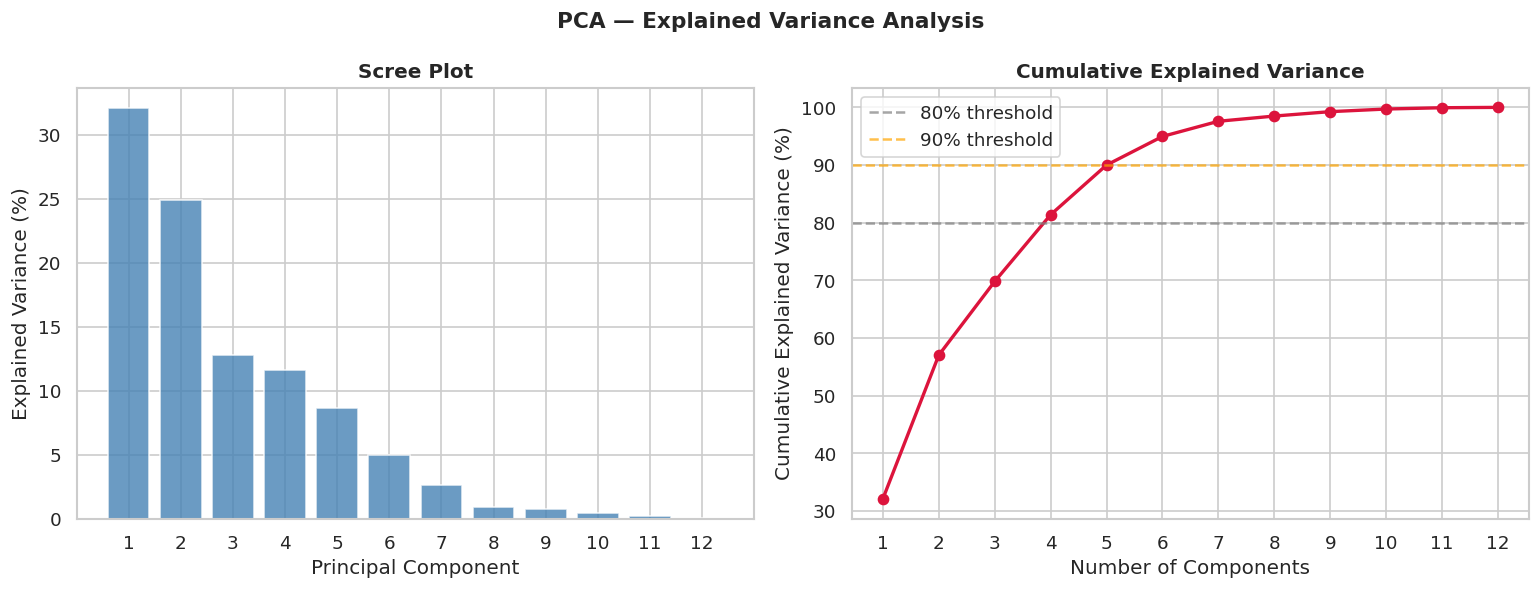

Components for 80% variance: 4
Components for 90% variance: 6

Using 6 components for clustering (95.0% variance retained)
2D PCA for visualisation (57.0% variance retained)


In [ ]:
# [SECTION 4 - METHODOLOGY] PCA — Dimensionality Reduction

# Full PCA to analyse explained variance
pca_full = PCA(random_state=SEED)
pca_full.fit(X_scaled)

explained = pca_full.explained_variance_ratio_
cumulative = np.cumsum(explained)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
ax1.bar(range(1, len(explained)+1), explained * 100, color='steelblue', alpha=0.8)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot', fontweight='bold')
ax1.set_xticks(range(1, len(explained)+1))

# Cumulative explained variance
ax2.plot(range(1, len(cumulative)+1), cumulative * 100, 'o-', color='crimson', linewidth=2)
ax2.axhline(80, color='gray', linestyle='--', alpha=0.7, label='80% threshold')
ax2.axhline(90, color='orange', linestyle='--', alpha=0.7, label='90% threshold')
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance', fontweight='bold')
ax2.legend()
ax2.set_xticks(range(1, len(cumulative)+1))

plt.suptitle('PCA — Explained Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('pca_variance.png', bbox_inches='tight', dpi=150)
plt.show()

# Report how many components for 80%/90%
n_80 = np.argmax(cumulative >= 0.80) + 1
n_90 = np.argmax(cumulative >= 0.90) + 1
print(f'Components for 80% variance: {n_80}')
print(f'Components for 90% variance: {n_90}')

# Use 2D PCA for visualisation; n_90 for modelling
pca_2d = PCA(n_components=2, random_state=SEED)
X_pca2 = pca_2d.fit_transform(X_scaled)

pca_model = PCA(n_components=n_90, random_state=SEED)
X_pca = pca_model.fit_transform(X_scaled)

print(f'\nUsing {n_90} components for clustering ({cumulative[n_90-1]*100:.1f}% variance retained)')
print(f'2D PCA for visualisation ({cumulative[1]*100:.1f}% variance retained)')

### 4.3 Model 1 — K-Means: Elbow Method & Silhouette Analysis

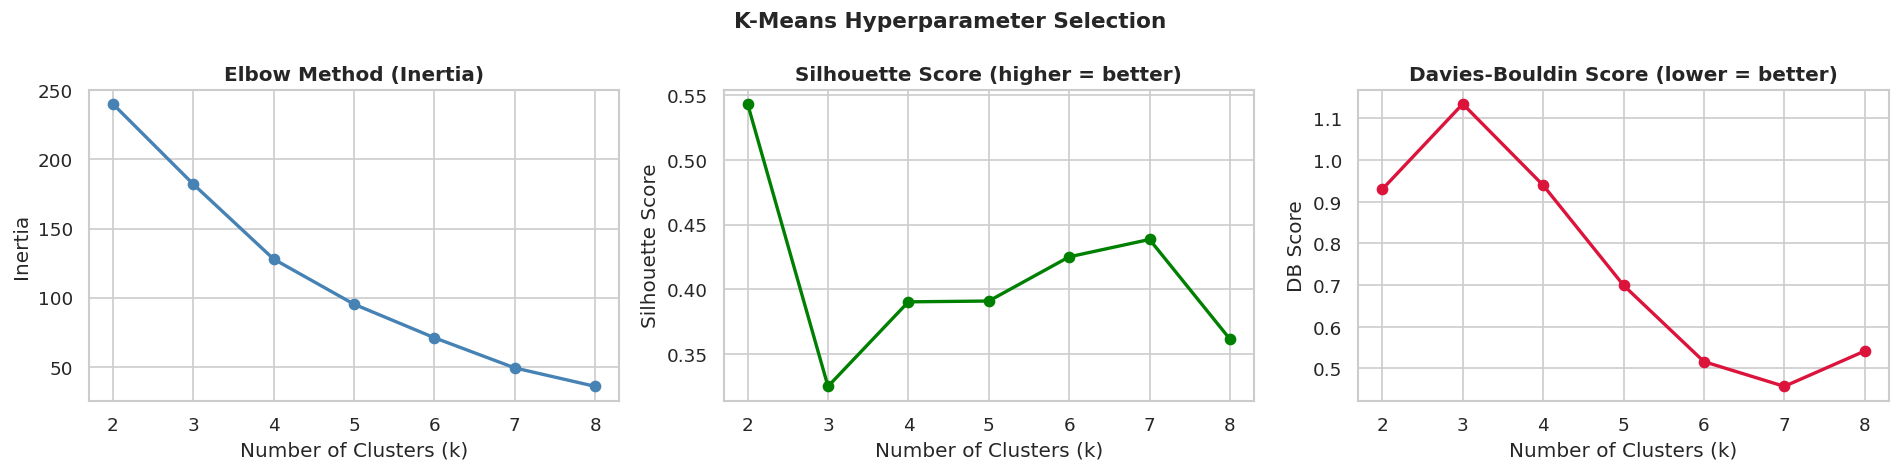

Best k by Silhouette Score: k = 2

Summary table:
 k  Inertia  Silhouette  Davies-Bouldin  Calinski-Harabasz
 2 240.0825      0.5433          0.9301            10.1635
 3 182.0789      0.3249          1.1346            10.5937
 4 127.8967      0.3902          0.9395            13.1981
 5  95.2742      0.3909          0.6995            14.8108
 6  71.0262      0.4250          0.5164            16.8019
 7  49.2086      0.4385          0.4571            20.9565
 8  35.8592      0.3614          0.5418            24.6461


In [ ]:
# [SECTION 4 - METHODOLOGY] K-Means — Optimal k Selection

K_RANGE = range(2, 9)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=20, max_iter=500)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_RANGE, inertias, 'o-', color='steelblue', linewidth=2)
axes[0].set_title('Elbow Method (Inertia)', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

axes[1].plot(K_RANGE, silhouettes, 'o-', color='green', linewidth=2)
axes[1].set_title('Silhouette Score (higher = better)', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

axes[2].plot(K_RANGE, db_scores, 'o-', color='crimson', linewidth=2)
axes[2].set_title('Davies-Bouldin Score (lower = better)', fontweight='bold')
axes[2].set_xlabel('Number of Clusters (k)')
axes[2].set_ylabel('DB Score')

plt.suptitle('K-Means Hyperparameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('kmeans_selection.png', bbox_inches='tight', dpi=150)
plt.show()

best_k = list(K_RANGE)[np.argmax(silhouettes)]
print(f'Best k by Silhouette Score: k = {best_k}')
print('\nSummary table:')
summary = pd.DataFrame({'k': list(K_RANGE), 'Inertia': inertias,
                         'Silhouette': silhouettes, 'Davies-Bouldin': db_scores,
                         'Calinski-Harabasz': ch_scores})
print(summary.round(4).to_string(index=False))

In [ ]:
# [SECTION 4 - METHODOLOGY] K-Means Final Model

OPTIMAL_K = best_k  # set from above analysis

kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=SEED, n_init=30, max_iter=500)
km_labels = kmeans.fit_predict(X_pca)

feat_df_clean['kmeans_cluster'] = km_labels
print(f'K-Means fitted with k={OPTIMAL_K}')
print('Cluster distribution:')
print(feat_df_clean['kmeans_cluster'].value_counts().sort_index())

K-Means fitted with k=2
Cluster distribution:
kmeans_cluster
0    27
1     2
Name: count, dtype: int64


### 4.4 Model 2 — DBSCAN

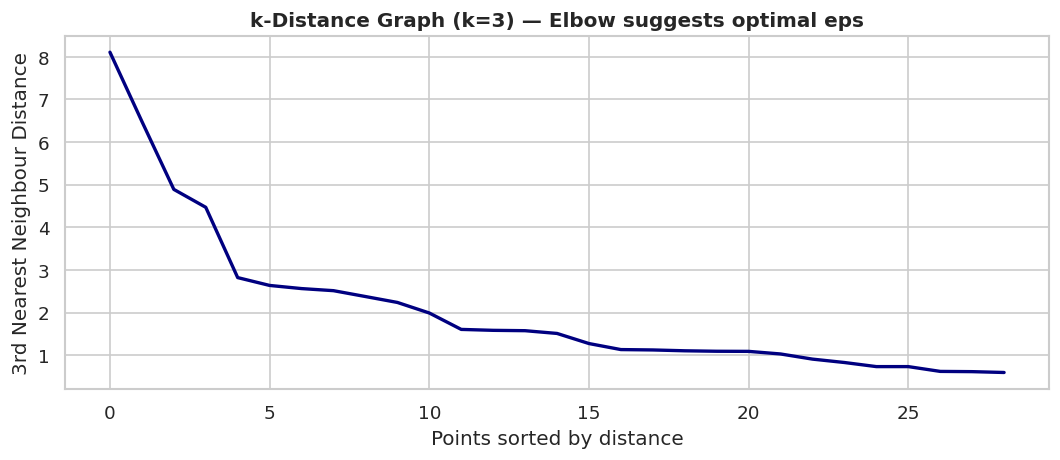


DBSCAN Grid Search:
 eps  min_samples  n_clusters  n_noise  silhouette
 0.5            2           0       29     -1.0000
 0.5            3           0       29     -1.0000
 0.5            4           0       29     -1.0000
 0.8            2           2       21     -0.1166
 0.8            3           2       21     -0.1166
 0.8            4           1       24     -1.0000
 1.0            2           2       19     -0.0773
 1.0            3           2       19     -0.0773
 1.0            4           1       23     -1.0000
 1.2            2           1       16     -1.0000
 1.2            3           1       16     -1.0000
 1.2            4           1       16     -1.0000
 1.5            2           2       10      0.3457
 1.5            3           1       12     -1.0000
 1.5            4           1       13     -1.0000
 2.0            2           3        6      0.3541
 2.0            3           1       10     -1.0000
 2.0            4           1       10     -1.0000

Best DBSC

In [ ]:
# [SECTION 4 - METHODOLOGY] DBSCAN — Hyperparameter Tuning via eps grid search
from sklearn.neighbors import NearestNeighbors

# Use k-distance graph to find optimal eps
nbrs = NearestNeighbors(n_neighbors=3).fit(X_pca)
distances, _ = nbrs.kneighbors(X_pca)
k_distances = np.sort(distances[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(k_distances, color='navy', linewidth=2)
ax.set_title('k-Distance Graph (k=3) — Elbow suggests optimal eps', fontweight='bold')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('3rd Nearest Neighbour Distance')
plt.tight_layout()
plt.savefig('dbscan_kdist.png', bbox_inches='tight', dpi=150)
plt.show()

# Grid search over eps and min_samples
print('\nDBSCAN Grid Search:')
best_dbscan, best_db_sil, best_eps, best_ms = None, -1, None, None
results = []
for eps in [0.5, 0.8, 1.0, 1.2, 1.5, 2.0]:
    for ms in [2, 3, 4]:
        db = DBSCAN(eps=eps, min_samples=ms)
        lbl = db.fit_predict(X_pca)
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise    = list(lbl).count(-1)
        sil = silhouette_score(X_pca, lbl) if n_clusters > 1 and n_clusters < len(lbl)-1 else -1
        results.append({'eps': eps, 'min_samples': ms,
                        'n_clusters': n_clusters, 'n_noise': n_noise, 'silhouette': round(sil, 4)})
        if sil > best_db_sil and n_clusters > 1:
            best_db_sil, best_eps, best_ms = sil, eps, ms
            best_dbscan = db

res_df = pd.DataFrame(results)
print(res_df.to_string(index=False))
print(f'\nBest DBSCAN: eps={best_eps}, min_samples={best_ms}, silhouette={best_db_sil:.4f}')

# Fit best DBSCAN
dbscan = DBSCAN(eps=best_eps, min_samples=best_ms)
db_labels = dbscan.fit_predict(X_pca)
feat_df_clean['dbscan_cluster'] = db_labels
print('Cluster distribution (−1 = noise/outlier):')
print(pd.Series(db_labels).value_counts().sort_index())

### 4.5 Model 3 — Gaussian Mixture Model (GMM)

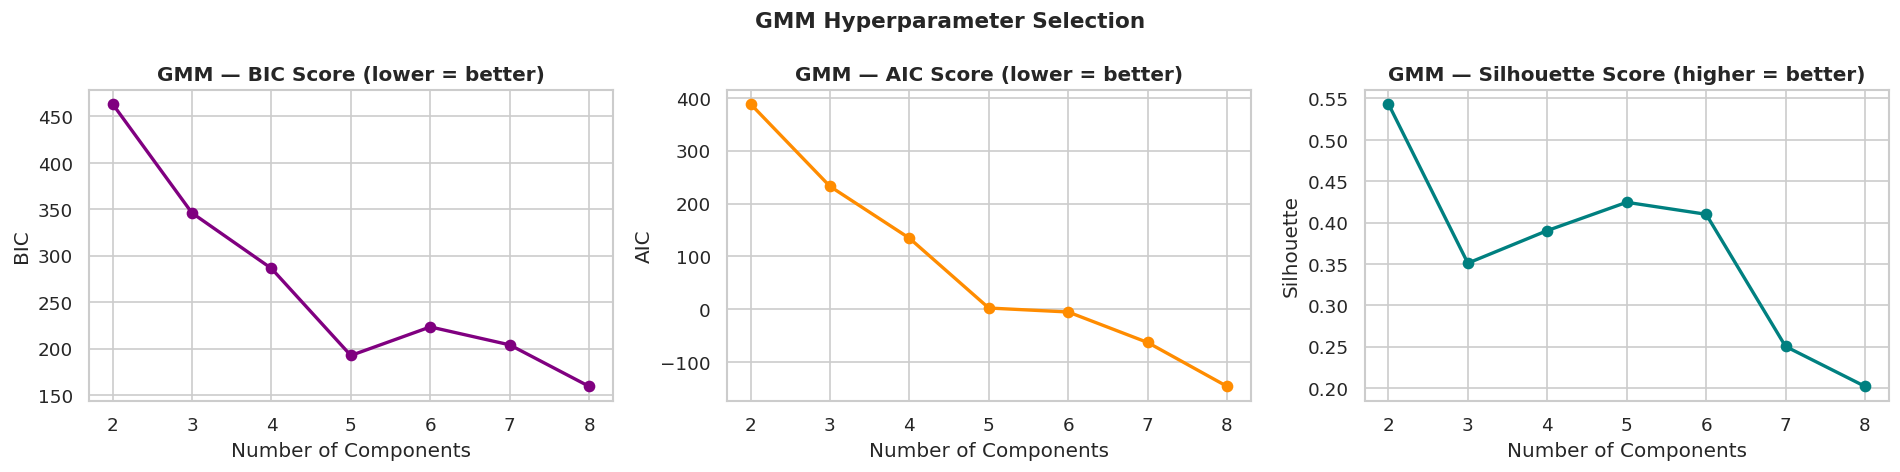

Best GMM components by BIC: n = 8
GMM Cluster distribution:
0     5
1     1
2     5
3     1
4     2
5     3
6     2
7    10
Name: count, dtype: int64


In [ ]:
# [SECTION 4 - METHODOLOGY] GMM — Component Selection via BIC/AIC

bic_scores, aic_scores, gmm_sils = [], [], []
covariance_type = 'full'

for n in K_RANGE:
    gmm = GaussianMixture(n_components=n, covariance_type=covariance_type,
                          random_state=SEED, max_iter=500, n_init=10)
    gmm.fit(X_pca)
    lbl = gmm.predict(X_pca)
    bic_scores.append(gmm.bic(X_pca))
    aic_scores.append(gmm.aic(X_pca))
    sil = silhouette_score(X_pca, lbl) if len(set(lbl)) > 1 else -1
    gmm_sils.append(sil)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(K_RANGE, bic_scores, 'o-', color='purple', linewidth=2)
axes[0].set_title('GMM — BIC Score (lower = better)', fontweight='bold')
axes[0].set_xlabel('Number of Components')
axes[0].set_ylabel('BIC')

axes[1].plot(K_RANGE, aic_scores, 'o-', color='darkorange', linewidth=2)
axes[1].set_title('GMM — AIC Score (lower = better)', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('AIC')

axes[2].plot(K_RANGE, gmm_sils, 'o-', color='teal', linewidth=2)
axes[2].set_title('GMM — Silhouette Score (higher = better)', fontweight='bold')
axes[2].set_xlabel('Number of Components')
axes[2].set_ylabel('Silhouette')

plt.suptitle('GMM Hyperparameter Selection', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('gmm_selection.png', bbox_inches='tight', dpi=150)
plt.show()

best_gmm_n = list(K_RANGE)[np.argmin(bic_scores)]
print(f'Best GMM components by BIC: n = {best_gmm_n}')

# Final GMM
gmm_final = GaussianMixture(n_components=best_gmm_n, covariance_type=covariance_type,
                             random_state=SEED, max_iter=500, n_init=10)
gmm_final.fit(X_pca)
gmm_labels = gmm_final.predict(X_pca)
gmm_probs  = gmm_final.predict_proba(X_pca)  # soft assignments

feat_df_clean['gmm_cluster'] = gmm_labels
print('GMM Cluster distribution:')
print(pd.Series(gmm_labels).value_counts().sort_index())

---
## [SECTION 5 - RESULTS] — Evaluation & Visualisation

### 5.1 Quantitative Evaluation — All Three Models

In [ ]:
# [SECTION 5 - RESULTS] Evaluation Metrics Comparison Table

def evaluate_model(name, labels, X):
    valid = labels != -1  # exclude DBSCAN noise
    X_v, lbl_v = X[valid], labels[valid]
    n_clusters = len(set(lbl_v))
    if n_clusters < 2:
        return {'Model': name, 'Clusters': n_clusters, 'Silhouette': 'N/A',
                'Davies-Bouldin': 'N/A', 'Calinski-Harabasz': 'N/A',
                'Noise Points': int((labels == -1).sum())}
    return {
        'Model':              name,
        'Clusters':           n_clusters,
        'Silhouette':         round(silhouette_score(X_v, lbl_v), 4),
        'Davies-Bouldin':     round(davies_bouldin_score(X_v, lbl_v), 4),
        'Calinski-Harabasz':  round(calinski_harabasz_score(X_v, lbl_v), 4),
        'Noise Points':       int((labels == -1).sum())
    }

eval_results = [
    evaluate_model('K-Means',  km_labels,  X_pca),
    evaluate_model('DBSCAN',   db_labels,  X_pca),
    evaluate_model('GMM',      gmm_labels, X_pca),
]

eval_df = pd.DataFrame(eval_results)
print('=== Clustering Model Evaluation Summary ===')
print(eval_df.to_string(index=False))

# Save for report
eval_df.to_csv('evaluation_metrics.csv', index=False)
print('\nSaved: evaluation_metrics.csv')

=== Clustering Model Evaluation Summary ===
  Model  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise Points
K-Means         2      0.5433          0.9301            10.1635             0
 DBSCAN         3      0.5306          0.4903            16.3524             6
    GMM         8      0.2020          0.9227            15.5311             0

Saved: evaluation_metrics.csv


### 5.2 PCA 2D Cluster Visualisation — All Models

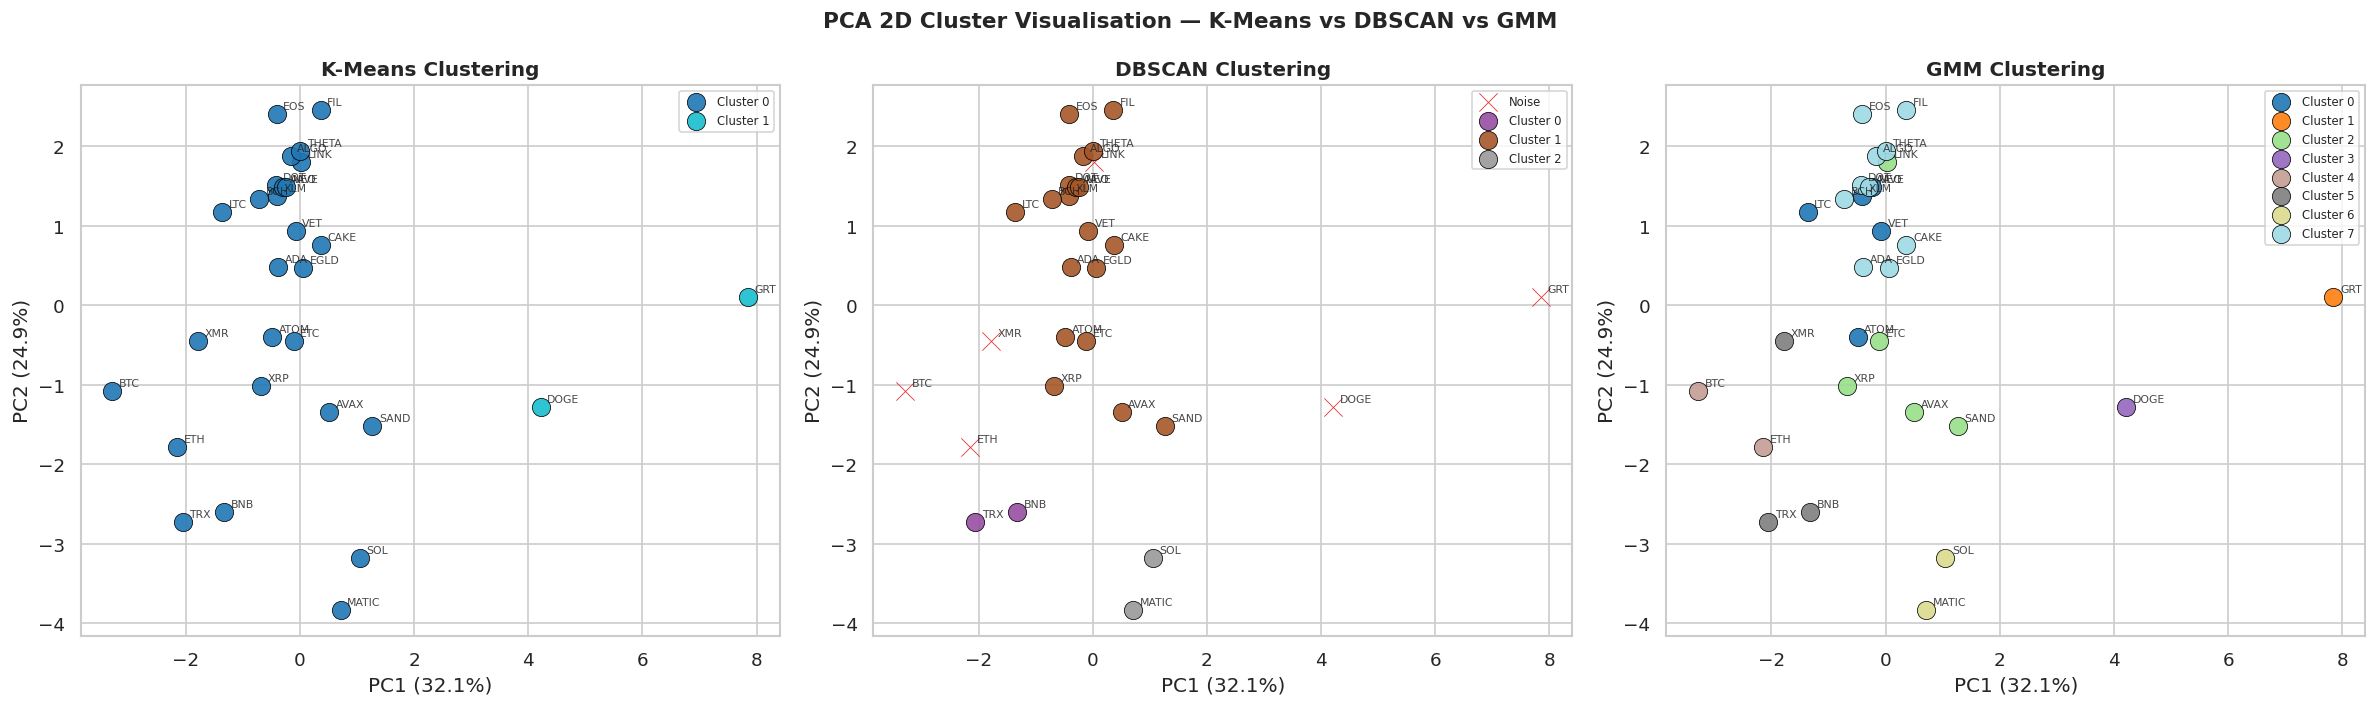

Figure saved: results_pca_clusters.png


In [ ]:
# [SECTION 5 - RESULTS] PCA 2D Cluster Plots

models = [
    ('K-Means',  km_labels,  'tab10'),
    ('DBSCAN',   db_labels,  'Set1'),
    ('GMM',      gmm_labels, 'tab20'),
]

tickers = feat_df_clean.index.tolist()

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for ax, (name, labels, cmap) in zip(axes, models):
    unique_labels = sorted(set(labels))
    colors = cm.get_cmap(cmap)(np.linspace(0, 1, len(unique_labels)))
    color_map = {lbl: c for lbl, c in zip(unique_labels, colors)}

    for lbl in unique_labels:
        mask = labels == lbl
        label_name = f'Noise' if lbl == -1 else f'Cluster {lbl}'
        marker = 'x' if lbl == -1 else 'o'
        ax.scatter(X_pca2[mask, 0], X_pca2[mask, 1],
                   c=[color_map[lbl]], label=label_name,
                   s=120, edgecolors='black', linewidths=0.5,
                   marker=marker, alpha=0.9)

    # Annotate coins
    for i, ticker in enumerate(tickers):
        ax.annotate(ticker, (X_pca2[i, 0], X_pca2[i, 1]),
                    textcoords='offset points', xytext=(4, 3), fontsize=6.5, alpha=0.85)

    ax.set_title(f'{name} Clustering', fontsize=12, fontweight='bold')
    ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)')
    ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)')
    ax.legend(fontsize=7, loc='best')

plt.suptitle('PCA 2D Cluster Visualisation — K-Means vs DBSCAN vs GMM',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_pca_clusters.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: results_pca_clusters.png')

### 5.3 Cluster Profiles — K-Means (Best Model)

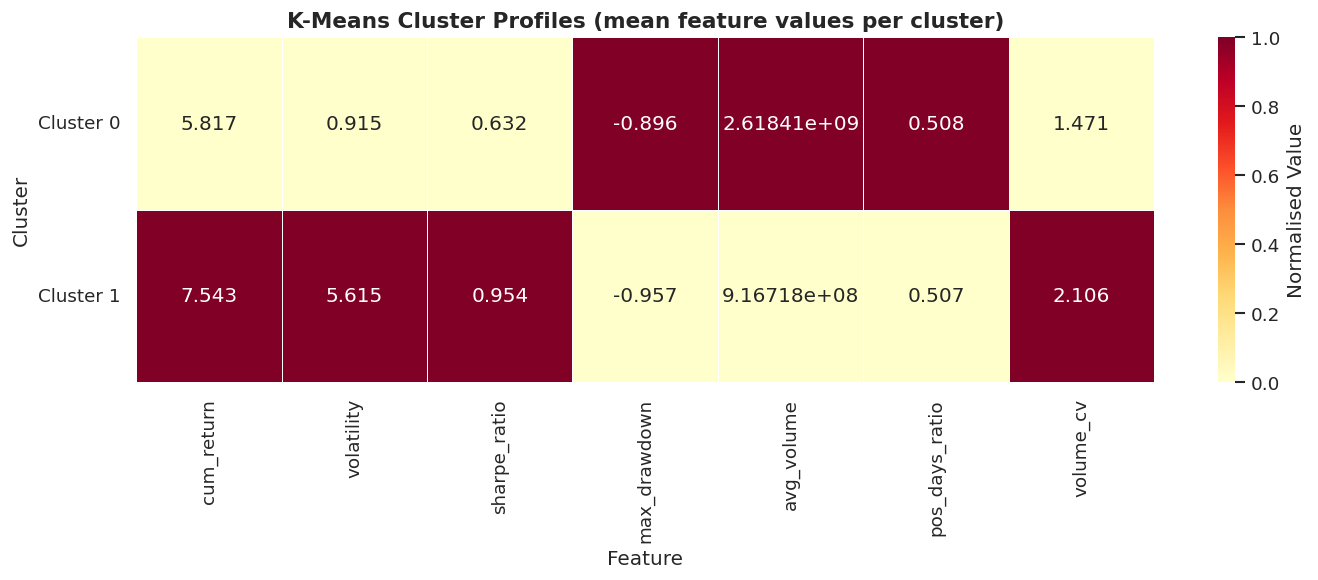

Figure saved: results_cluster_profiles.png

Cluster means:
                cum_return  volatility  sharpe_ratio  max_drawdown    avg_volume  pos_days_ratio  volume_cv
kmeans_cluster                                                                                             
0                   5.8167      0.9153        0.6318       -0.8958  2.618413e+09           0.508     1.4706
1                   7.5433      5.6153        0.9541       -0.9570  9.167176e+08           0.507     2.1061


In [ ]:
# [SECTION 5 - RESULTS] Cluster Profile Heatmap (K-Means)

profile_features = ['cum_return', 'volatility', 'sharpe_ratio',
                    'max_drawdown', 'avg_volume', 'pos_days_ratio', 'volume_cv']

cluster_profiles = feat_df_clean.groupby('kmeans_cluster')[profile_features].mean()

# Normalise for heatmap readability
from sklearn.preprocessing import MinMaxScaler
profile_scaled = pd.DataFrame(
    MinMaxScaler().fit_transform(cluster_profiles),
    index=cluster_profiles.index,
    columns=cluster_profiles.columns
)

fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(profile_scaled, annot=cluster_profiles.round(3), fmt='g',
            cmap='YlOrRd', linewidths=0.5, ax=ax, cbar_kws={'label': 'Normalised Value'})
ax.set_title('K-Means Cluster Profiles (mean feature values per cluster)',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Cluster')
ax.set_yticklabels([f'Cluster {i}' for i in cluster_profiles.index], rotation=0)
plt.tight_layout()
plt.savefig('results_cluster_profiles.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: results_cluster_profiles.png')
print('\nCluster means:')
print(cluster_profiles.round(4).to_string())

### 5.4 Cluster Membership — Which Coins in Which Cluster?

=== Cluster Membership per Model ===

K-Means Cluster 0 (27 coins): ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'SOL', 'DOT', 'MATIC', 'LTC', 'AVAX', 'LINK', 'XLM', 'ATOM', 'ETC', 'XMR', 'BCH', 'ALGO', 'VET', 'FIL', 'TRX', 'THETA', 'EOS', 'AAVE', 'NEO', 'CAKE', 'EGLD', 'SAND']

K-Means Cluster 1 (2 coins): ['DOGE', 'GRT']


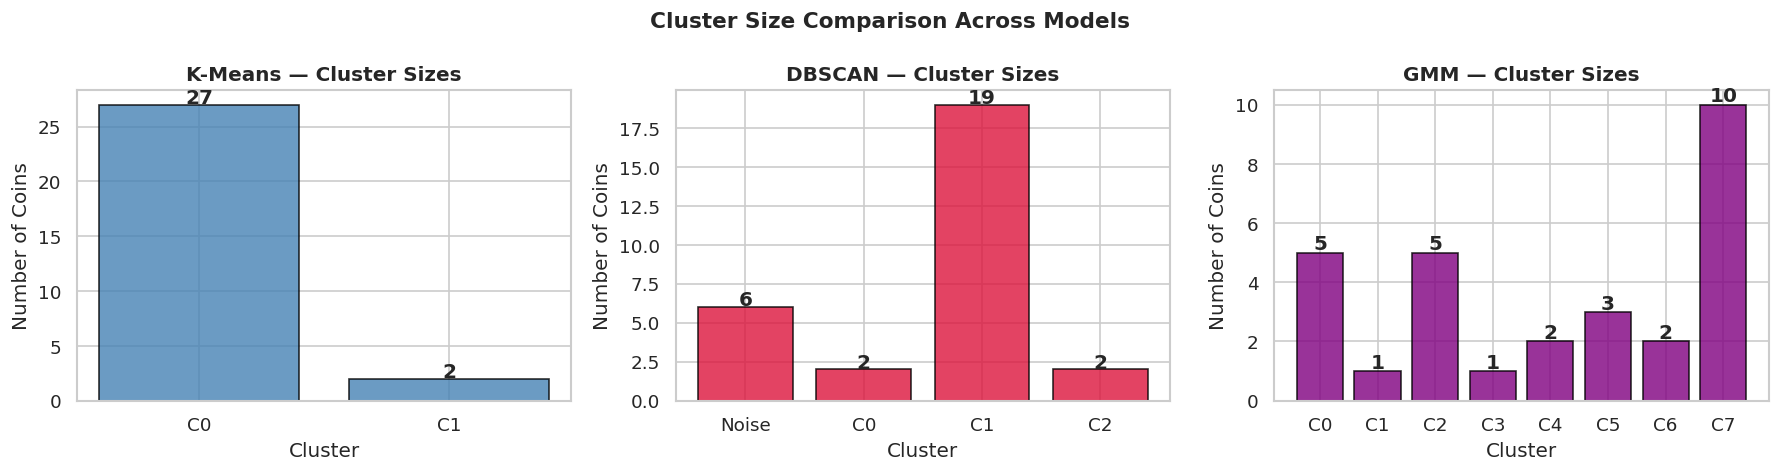

Figure saved: results_cluster_sizes.png


In [ ]:
# [SECTION 5 - RESULTS] Cluster Membership Summary

membership = feat_df_clean[['kmeans_cluster', 'gmm_cluster', 'dbscan_cluster']].copy()
membership.index.name = 'Cryptocurrency'

print('=== Cluster Membership per Model ===')
for c in range(OPTIMAL_K):
    coins = membership[membership['kmeans_cluster'] == c].index.tolist()
    print(f'\nK-Means Cluster {c} ({len(coins)} coins): {coins}')

# Bar chart of cluster sizes
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (col, name, color) in zip(axes, [
    ('kmeans_cluster', 'K-Means', 'steelblue'),
    ('dbscan_cluster', 'DBSCAN',  'crimson'),
    ('gmm_cluster',    'GMM',     'purple')
]):
    counts = membership[col].value_counts().sort_index()
    labels_bar = [f'Noise' if x == -1 else f'C{x}' for x in counts.index]
    ax.bar(labels_bar, counts.values, color=color, alpha=0.8, edgecolor='black')
    ax.set_title(f'{name} — Cluster Sizes', fontweight='bold')
    ax.set_xlabel('Cluster')
    ax.set_ylabel('Number of Coins')
    for i, v in enumerate(counts.values):
        ax.text(i, v + 0.1, str(v), ha='center', fontweight='bold')

plt.suptitle('Cluster Size Comparison Across Models', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('results_cluster_sizes.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: results_cluster_sizes.png')

### 5.5 GMM Soft Assignment Probability Heatmap

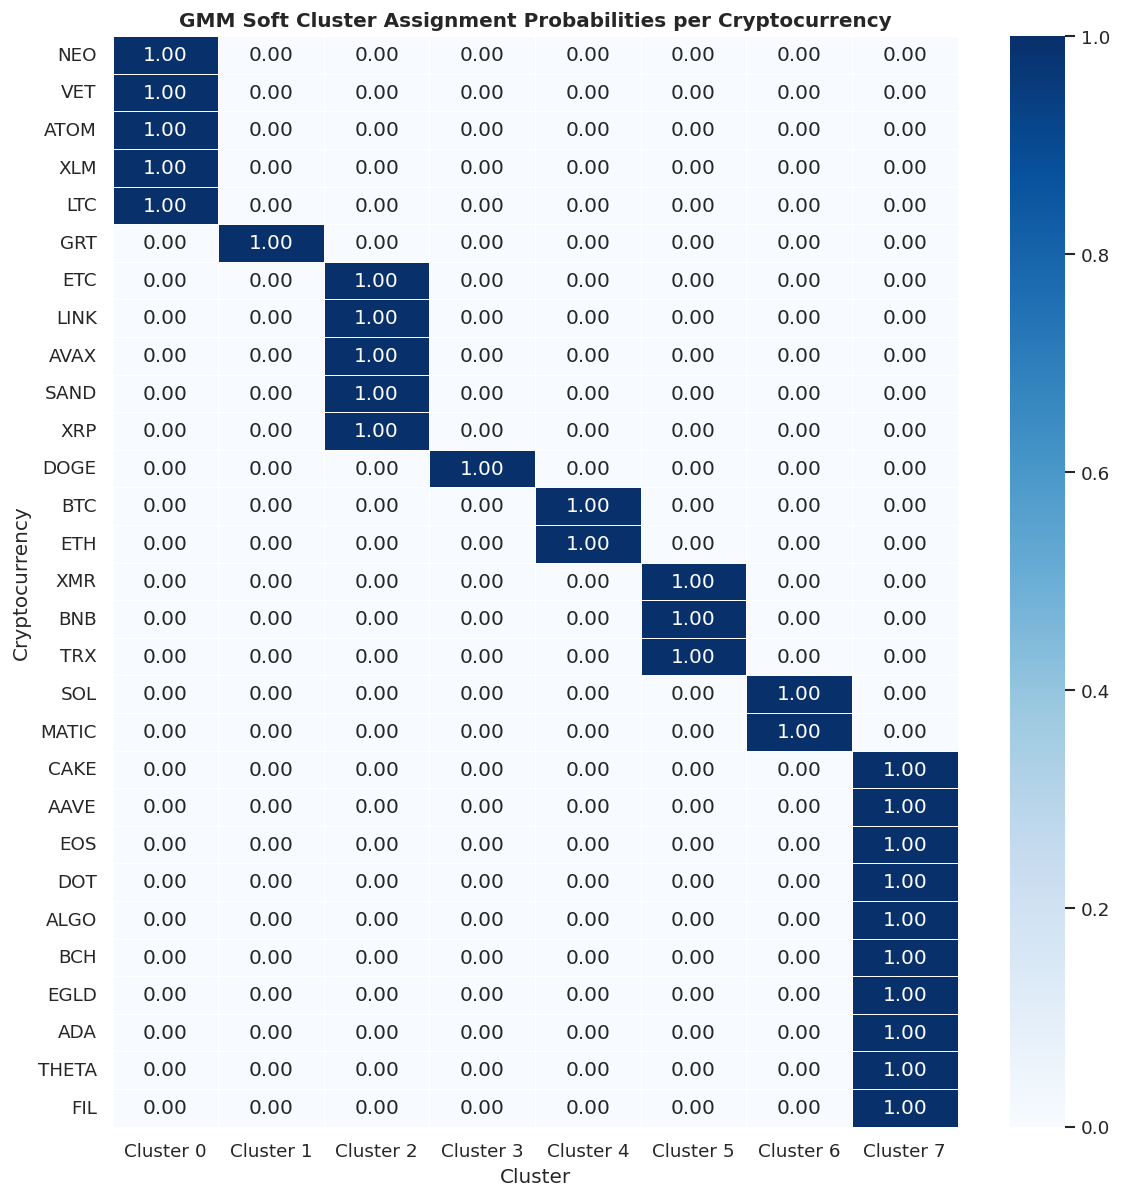

Figure saved: results_gmm_probs.png

High-uncertainty coins (max prob < 0.7):
None — all coins have clear dominant cluster


In [ ]:
# [SECTION 5 - RESULTS] GMM Soft Probability Heatmap

prob_df = pd.DataFrame(
    gmm_probs,
    index=feat_df_clean.index,
    columns=[f'Cluster {i}' for i in range(best_gmm_n)]
)

# Sort by most probable cluster
prob_df['dominant'] = prob_df.idxmax(axis=1)
prob_df_sorted = prob_df.sort_values('dominant').drop(columns='dominant')

fig, ax = plt.subplots(figsize=(10, max(6, len(prob_df_sorted)*0.35)))
sns.heatmap(prob_df_sorted, annot=True, fmt='.2f', cmap='Blues',
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title('GMM Soft Cluster Assignment Probabilities per Cryptocurrency',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Cryptocurrency')
plt.tight_layout()
plt.savefig('results_gmm_probs.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: results_gmm_probs.png')
print('\nHigh-uncertainty coins (max prob < 0.7):')
uncertain = prob_df[prob_df.drop(columns='dominant').max(axis=1) < 0.7]
print(uncertain.round(3) if len(uncertain) > 0 else 'None — all coins have clear dominant cluster')

### 5.6 Radar Chart — Cluster Behavioural Fingerprints

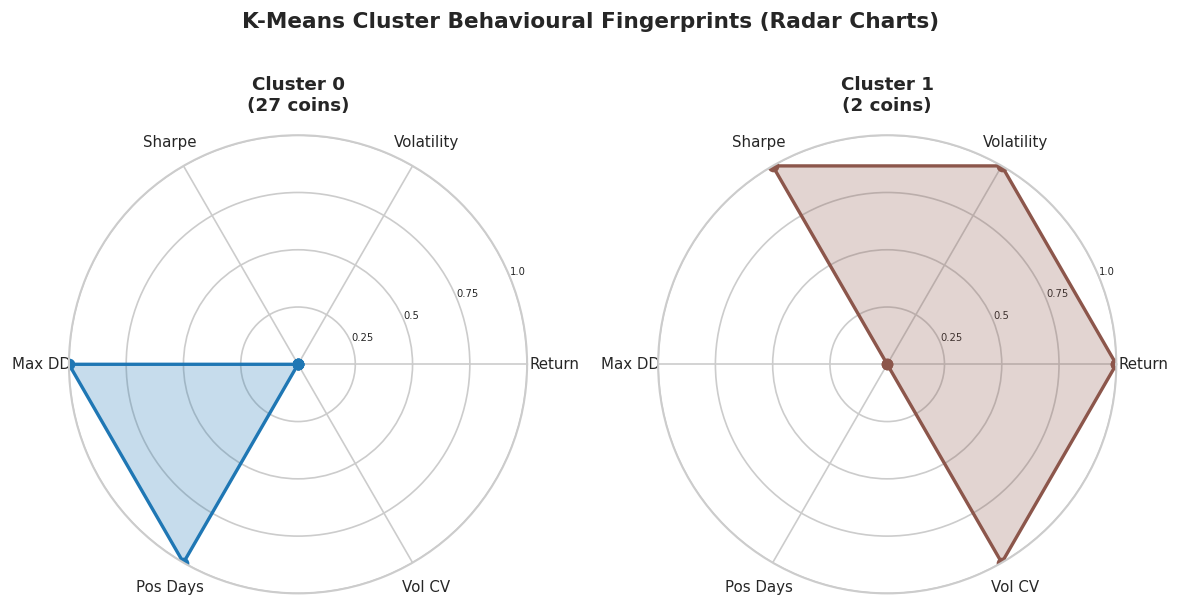

Figure saved: results_radar.png


In [ ]:
# [SECTION 5 - RESULTS] Radar Chart — K-Means Cluster Fingerprints

from matplotlib.patches import FancyArrowPatch
import matplotlib.patheffects as pe

radar_features = ['cum_return', 'volatility', 'sharpe_ratio',
                  'max_drawdown', 'pos_days_ratio', 'volume_cv']
radar_labels   = ['Return', 'Volatility', 'Sharpe', 'Max DD', 'Pos Days', 'Vol CV']

# Normalise profiles to [0,1]
radar_data_raw = feat_df_clean.groupby('kmeans_cluster')[radar_features].mean()
radar_data = (radar_data_raw - radar_data_raw.min()) / (radar_data_raw.max() - radar_data_raw.min() + 1e-9)

N = len(radar_features)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, axes = plt.subplots(1, OPTIMAL_K, figsize=(5*OPTIMAL_K, 5), subplot_kw=dict(polar=True))
if OPTIMAL_K == 1:
    axes = [axes]

palette = plt.cm.tab10(np.linspace(0, 0.5, OPTIMAL_K))

for i, (ax, cluster_id) in enumerate(zip(axes, radar_data.index)):
    values = radar_data.loc[cluster_id].tolist()
    values += values[:1]
    ax.plot(angles, values, 'o-', linewidth=2, color=palette[i])
    ax.fill(angles, values, alpha=0.25, color=palette[i])
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(radar_labels, fontsize=9)
    ax.set_ylim(0, 1)
    n_coins = (feat_df_clean['kmeans_cluster'] == cluster_id).sum()
    ax.set_title(f'Cluster {cluster_id}\n({n_coins} coins)',
                 fontsize=11, fontweight='bold', pad=15)
    ax.set_yticks([0.25, 0.5, 0.75, 1.0])
    ax.set_yticklabels(['0.25','0.5','0.75','1.0'], fontsize=6)

plt.suptitle('K-Means Cluster Behavioural Fingerprints (Radar Charts)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('results_radar.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure saved: results_radar.png')

### 5.7 Final Summary — All Metrics in One Table

In [ ]:
# [SECTION 5 - RESULTS] Final Consolidated Summary

print('=' * 65)
print('       FINAL CLUSTERING EVALUATION SUMMARY')
print('=' * 65)
print(eval_df.to_string(index=False))
print('=' * 65)
print('Note: Higher Silhouette & Calinski-Harabasz = better separation')
print('      Lower Davies-Bouldin = better cluster compactness')
print('      DBSCAN −1 labels indicate outlier/noise coins')

print('\n=== K-Means Cluster Membership ===')
for c in sorted(feat_df_clean['kmeans_cluster'].unique()):
    coins = feat_df_clean[feat_df_clean['kmeans_cluster'] == c].index.tolist()
    print(f'  Cluster {c}: {coins}')

print('\n=== DBSCAN Results ===')
for c in sorted(feat_df_clean['dbscan_cluster'].unique()):
    coins = feat_df_clean[feat_df_clean['dbscan_cluster'] == c].index.tolist()
    label = 'Outliers (Noise)' if c == -1 else f'Cluster {c}'
    print(f'  {label}: {coins}')

print('\n=== GMM Cluster Membership ===')
for c in sorted(feat_df_clean['gmm_cluster'].unique()):
    coins = feat_df_clean[feat_df_clean['gmm_cluster'] == c].index.tolist()
    print(f'  Cluster {c}: {coins}')

       FINAL CLUSTERING EVALUATION SUMMARY
  Model  Clusters  Silhouette  Davies-Bouldin  Calinski-Harabasz  Noise Points
K-Means         2      0.5433          0.9301            10.1635             0
 DBSCAN         3      0.5306          0.4903            16.3524             6
    GMM         8      0.2020          0.9227            15.5311             0
Note: Higher Silhouette & Calinski-Harabasz = better separation
      Lower Davies-Bouldin = better cluster compactness
      DBSCAN −1 labels indicate outlier/noise coins

=== K-Means Cluster Membership ===
  Cluster 0: ['BTC', 'ETH', 'BNB', 'XRP', 'ADA', 'SOL', 'DOT', 'MATIC', 'LTC', 'AVAX', 'LINK', 'XLM', 'ATOM', 'ETC', 'XMR', 'BCH', 'ALGO', 'VET', 'FIL', 'TRX', 'THETA', 'EOS', 'AAVE', 'NEO', 'CAKE', 'EGLD', 'SAND']
  Cluster 1: ['DOGE', 'GRT']

=== DBSCAN Results ===
  Outliers (Noise): ['BTC', 'ETH', 'DOGE', 'LINK', 'XMR', 'GRT']
  Cluster 0: ['BNB', 'TRX']
  Cluster 1: ['XRP', 'ADA', 'DOT', 'LTC', 'AVAX', 'XLM', 'ATOM', 'ETC', 

---
## APPENDIX — Save All Outputs

In [ ]:
# Save full results table as CSV (include in appendix)
final_table = feat_df_clean.copy()
final_table.to_csv('full_results_table.csv')
print('Saved: full_results_table.csv')

# List all saved figures
import glob
saved_files = glob.glob('*.png') + glob.glob('*.csv')
print('\nAll saved output files:')
for f in sorted(saved_files):
    print(f'  {f}')

print('\n✓ All outputs ready. Screenshots these figures for your report.')

Saved: full_results_table.csv

All saved output files:
  dbscan_kdist.png
  eda_correlation.png
  eda_distributions.png
  eda_pairplot.png
  eda_risk_return.png
  evaluation_metrics.csv
  full_results_table.csv
  gmm_selection.png
  kmeans_selection.png
  pca_variance.png
  results_cluster_profiles.png
  results_cluster_sizes.png
  results_gmm_probs.png
  results_pca_clusters.png
  results_radar.png

✓ All outputs ready. Screenshots these figures for your report.
